# Be²⁺ and BeCl₂ in water — force-field comparison
## Preamble

| System | Force field | Frames | Atoms |
|---|---|---|---|
| Be²⁺ | MACE-MP-0 | 10 001 | 337 (Be + 112 H₂O) |
| BeCl₂ | MACE-MP-0 | 10 001 | 339 (BeCl₂ + 112 H₂O) |
| Be²⁺ | MACE-POLAR-1-M | 10 001 | 337 |
| BeCl₂ | MACE-POLAR-1-M | 10 001 | 339 |

**Colour:** Be²⁺ = `cset[0]`, BeCl₂ = `cset[1]` (Paul Tol bright).  
**Line style:** MACE-MP-0 = solid, MACE-POLAR-1-M = dashed.

In [30]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from chempiler import ChempilerTrajectory, diffusive_window
from chempiler.vdos import read_vdos, smooth

import tol_colors as tc
cset = tc.bright

plt.rcParams.update({
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.prop_cycle': plt.cycler(color=cset),
})

dt            = 0.5   # fs per MD step
dump_interval = 10    # frames subsampled every 10 steps
dt_per_frame  = dt * dump_interval * 1e-3  # ps per frame

DATA = Path('../data')

TRAJS = {
    ('Be2+',  'MP0'):   DATA / 'MACE-MP-0/112_water/Be2+/112_water_Be.traj',
    ('BeCl2', 'MP0'):   DATA / 'MACE-MP-0/112_water/BeCl2/112_water_BeCl2.traj',
    ('Be2+',  'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/Be2+/112_water_Be_polar.traj',
    ('BeCl2', 'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/BeCl2/112_water_BeCl2_polar.traj',
}

LOGS = {
    ('Be2+',  'MP0'):   DATA / 'MACE-MP-0/112_water/Be2+/112_water_Be.log',
    ('BeCl2', 'MP0'):   DATA / 'MACE-MP-0/112_water/BeCl2/112_water_BeCl2.log',
    ('Be2+',  'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/Be2+/112_water_Be_polar.log',
    ('BeCl2', 'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/BeCl2/112_water_BeCl2_polar.log',
}

TRAVIS = {
    ('Be2+',  'MP0'):   DATA / 'MACE-MP-0/112_water/Be2+/travis/',
    ('BeCl2', 'MP0'):   DATA / 'MACE-MP-0/112_water/BeCl2/travis/',
    ('Be2+',  'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/Be2+/travis/',
    ('BeCl2', 'POLAR'): DATA / 'MACE-POLAR-1-M/112_water_Be/BeCl2/travis/',
}

# Colour = species; line style = force field
C  = {'Be2+': cset[0], 'BeCl2': cset[1]}
LS = {'MP0': '--', 'POLAR': '-'}
LW = 1.5

LABELS = {
    ('Be2+',  'MP0'):   r'Be$^{2+}$ MACE-MP-0',
    ('BeCl2', 'MP0'):   r'BeCl$_2$ MACE-MP-0',
    ('Be2+',  'POLAR'): r'Be$^{2+}$ MACE-POLAR-1-M',
    ('BeCl2', 'POLAR'): r'BeCl$_2$ MACE-POLAR-1-M',
}
FF_LABELS  = {'MP0': 'MACE-MP-0', 'POLAR': 'MACE-POLAR-1-M'}
SYS_LABELS = {'Be2+': r'Be$^{2+}$(aq)', 'BeCl2': r'BeCl$_2$(aq)'}

def load_travis(key, fname):
    """Load a Travis RDF CSV. Returns (r_Å, g, cumulative_n) arrays."""
    df = pd.read_csv(TRAVIS[key] / fname, sep=';')
    df.columns = df.columns.str.strip()
    r = df.iloc[:, 0].values / 100   # pm → Å
    return r, df.iloc[:, 1].values, df.iloc[:, 2].values

def load_vacf(logpath):
    """Load VACF column from a log file. Returns (t_fs, vacf) arrays."""
    data = pd.read_csv(logpath, sep=r'\s+', header=None, skiprows=1)
    vacf = data[8].to_numpy(dtype=float)
    return np.arange(len(vacf)) * dt, vacf

def fit_D(lags, msd, mask):
    """Fit D (m²/s) from MSD vs lag over the diffusive window."""
    c = np.polyfit(lags[mask], msd[mask], 1)
    return c[0] / 6 * 1e-20 / (dt * dump_interval * 1e-15)

print('Setup complete.')
for k, p in TRAJS.items():
    print(f'  {LABELS[k]}: {"found" if p.exists() else "MISSING"}')

Setup complete.
  Be$^{2+}$ MACE-MP-0: found
  BeCl$_2$ MACE-MP-0: found
  Be$^{2+}$ MACE-POLAR-1-M: found
  BeCl$_2$ MACE-POLAR-1-M: found


In [12]:
trajs = {}
cache_names = {
    ('Be2+',  'MP0'):   'tests/be_mp0_ion_cache.h5',
    ('BeCl2', 'MP0'):   'tests/be_mp0_cl_cache.h5',
    ('Be2+',  'POLAR'): 'tests/be_pol_ion_cache.h5',
    ('BeCl2', 'POLAR'): 'tests/be_pol_cl_cache.h5',
}
for key, path in TRAJS.items():
    print(f'Loading {LABELS[key]} ...', end=' ', flush=True)
    t = ChempilerTrajectory(str(path), mode='molecular', covalent_scale=1.0)
    t.build(cache_file=cache_names[key])
    trajs[key] = t
    print('done.')

Loading Be$^{2+}$ MACE-MP-0 ... [Chempiler] loaded cache → tests/be_mp0_ion_cache.h5
done.
Loading BeCl$_2$ MACE-MP-0 ... [Chempiler] loaded cache → tests/be_mp0_cl_cache.h5
done.
Loading Be$^{2+}$ MACE-POLAR-1-M ... [Chempiler] loaded cache → tests/be_pol_ion_cache.h5
done.
Loading BeCl$_2$ MACE-POLAR-1-M ... [Chempiler] loaded cache → tests/be_pol_cl_cache.h5
done.


---
## Species summary

In [13]:
all_forms = sorted(
    {f for t in trajs.values() for f in t.summary()},
    key=lambda f: -sum(t.summary().get(f, 0) for t in trajs.values()),
)
rows = [
    {**{'System': LABELS[k]},
     **{f: round(t.summary().get(f, 0) / len(t.frames), 4) for f in all_forms}}
    for k, t in trajs.items()
]
pd.DataFrame(rows).set_index('System')[all_forms]

,H2O,H4O2,Cl,H6O3,BeH10O5,BeH12O6,H8O4,BeH14O7,BeH8O4,BeH16O8,...,ClH14O7,BeH36O18,BeClH24O12,BeClH16O8,Cl2H4O2,BeClH26O13,BeClH20O10,BeClH14O7,H24O12,BeClH22O11
System,,,,,,,,,,,,,,,,,,,,,
Be$^{2+}$ MACE-MP-0,83.5721,7.6570,0.0000,1.3639,0.1308,0.2208,0.3053,0.2313,0.0347,0.1755,...,0.0000,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BeCl$_2$ MACE-MP-0,79.9380,8.4678,1.7823,1.7296,0.1570,0.2379,0.4193,0.2287,0.0495,0.1484,...,0.0003,0.0001,0.0002,0.0001,0.0002,0.0001,0.0001,0.0000,0.0001,0.0001
Be$^{2+}$ MACE-POLAR-1-M,104.6688,1.0172,0.0000,0.0226,0.4009,0.2482,0.0006,0.0794,0.2498,0.0188,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BeCl$_2$ MACE-POLAR-1-M,104.5114,1.0032,1.9387,0.0248,0.3826,0.2719,0.0006,0.0997,0.2137,0.0244,...,0.0000,0.0000,0.0000,0.0001,0.0000,0.0000,0.0000,0.0001,0.0000,0.0000


---
## Solvation structure (Travis RDFs)

Pre-computed RDFs from TRAVIS. Distances in pm, converted to Å.

### Be–O first-shell coordination

System                                Peak (Å)   1st-shell CN
-------------------------------------------------------------
  Be$^{2+}$ MACE-MP-0                     1.65           4.00
  Be$^{2+}$ MACE-POLAR-1-M                1.62           4.00
  BeCl$_2$ MACE-MP-0                      1.62           4.00
  BeCl$_2$ MACE-POLAR-1-M                 1.62           4.00


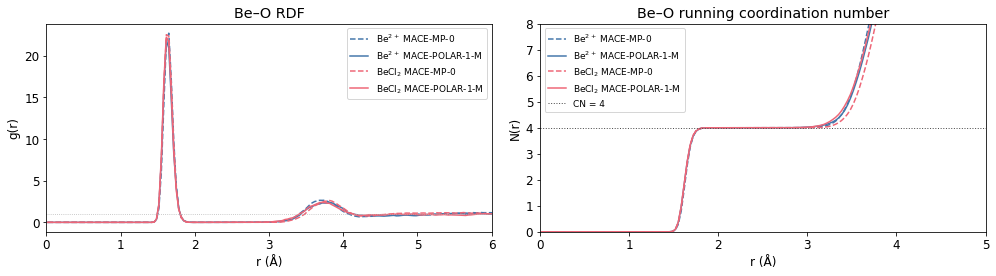

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, sys in enumerate(('Be2+', 'BeCl2')):
    for j, ff in enumerate(('MP0', 'POLAR')):
        r, g, n = load_travis((sys, ff), 'rdf_Be_O_[Be1r_O1o].csv')
        axes[0].plot(r, g, color=cset[i], ls=LS[ff], label=LABELS[(sys, ff)])
        axes[1].plot(r, n, color=cset[i], ls=LS[ff], label=LABELS[(sys, ff)])

axes[0].axhline(1, color='0.7', lw=0.8, ls=':')
axes[0].set_xlim(0, 6)
axes[0].set_xlabel('r (Å)')
axes[0].set_ylabel('g(r)')
axes[0].set_title('Be–O RDF')
axes[0].legend(fontsize=9)

axes[1].axhline(4, color='0.3', lw=1, ls=':', label='CN = 4')
axes[1].set_xlim(0, 5)
axes[1].set_ylim(0, 8)
axes[1].set_xlabel('r (Å)')
axes[1].set_ylabel('N(r)')
axes[1].set_title('Be–O running coordination number')
axes[1].legend(fontsize=9)

plt.tight_layout()

print(f'{"System":<35} {"Peak (Å)":>10} {"1st-shell CN":>14}')
print('-' * 61)
for sys in ('Be2+', 'BeCl2'):
    for ff in ('MP0', 'POLAR'):
        r, g, n = load_travis((sys, ff), 'rdf_Be_O_[Be1r_O1o].csv')
        pk_i = int(np.argmax(g))
        mn_i = pk_i + int(g[pk_i:pk_i + 30].argmin())
        print(f'  {LABELS[(sys, ff)]:<33} {r[pk_i]:>10.2f} {n[mn_i]:>14.2f}')

### Second solvation shell: Be[O]–O

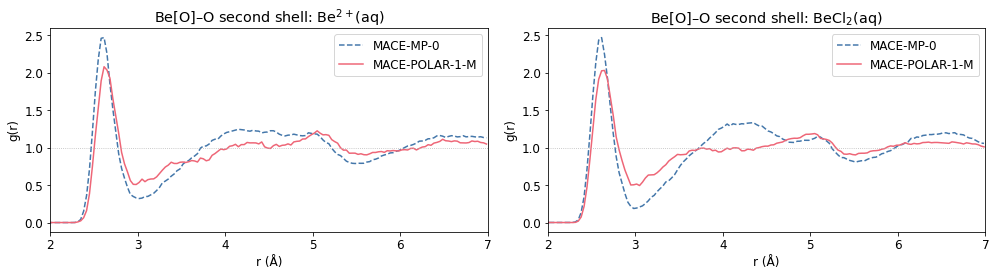

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, sys in enumerate(('Be2+', 'BeCl2')):
    for j, ff in enumerate(('MP0', 'POLAR')):
        r, g, _ = load_travis((sys, ff), 'rdf_BeH8O4_H2O_[Or_Oo].csv')
        axes[i].plot(r, g, color=cset[j], ls=LS[ff], lw=LW, label=FF_LABELS[ff])
    axes[i].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[i].set_xlim(2, 7)
    axes[i].set_xlabel('r (Å)')
    axes[i].set_ylabel('g(r)')
    axes[i].set_title(f'Be[O]–O second shell: {SYS_LABELS[sys]}')
    axes[i].legend()

plt.tight_layout()

### H₂O–H₂O O–O in ionic solutions

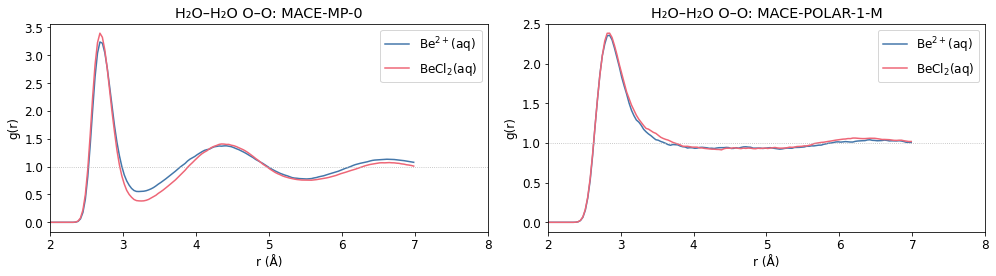

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, ff in enumerate(('MP0', 'POLAR')):
    for sys in ('Be2+', 'BeCl2'):
        r, g, _ = load_travis((sys, ff), 'rdf_H2O_H2O_[Or_Oo].csv')
        axes[i].plot(r, g, color=C[sys], ls=LS[ff], lw=LW, label=SYS_LABELS[sys])
    axes[i].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[i].set_xlim(2, 8)
    axes[i].set_xlabel('r (Å)')
    axes[i].set_ylabel('g(r)')
    axes[i].set_title(f'H₂O–H₂O O–O: {FF_LABELS[ff]}')
    axes[i].legend()

plt.tight_layout()

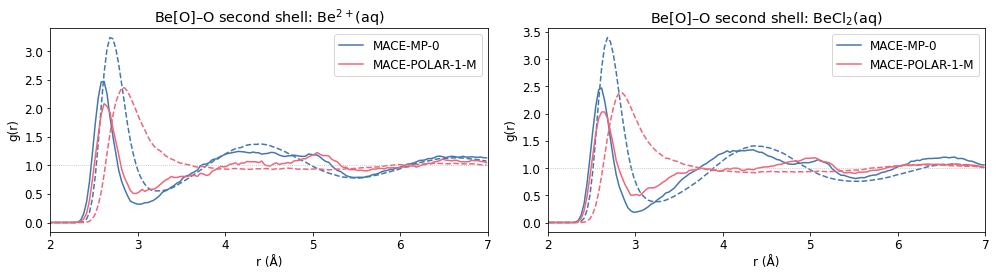

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, sys in enumerate(('Be2+', 'BeCl2')):
    for j, ff in enumerate(('MP0', 'POLAR')):
        r, g, _ = load_travis((sys, ff), 'rdf_BeH8O4_H2O_[Or_Oo].csv')
        rw, gw, _ = load_travis((sys, ff), 'rdf_H2O_H2O_[Or_Oo].csv')

        axes[i].plot(r, g, color=cset[j], lw=LW, label=FF_LABELS[ff])
        axes[i].plot(rw, gw, color=cset[j], ls='--')
    
    axes[i].axhline(1, color='0.7', lw=0.8, ls=':')
    axes[i].set_xlim(2, 7)
    axes[i].set_xlabel('r (Å)')
    axes[i].set_ylabel('g(r)')
    axes[i].set_title(f'Be[O]–O second shell: {SYS_LABELS[sys]}')
    axes[i].legend()

plt.tight_layout()

### Be–Cl association (BeCl₂ only)

MACE-MP-0 shows no Be–Cl correlation beyond ~2.5 Å, implying complete dissociation;
MACE-POLAR-1-M retains a first-shell Be–Cl peak, indicating partial association.

MACE-MP-0             : peak 7.98 Å   CN = 0.08
MACE-POLAR-1-M        : peak 7.12 Å   CN = 1.73


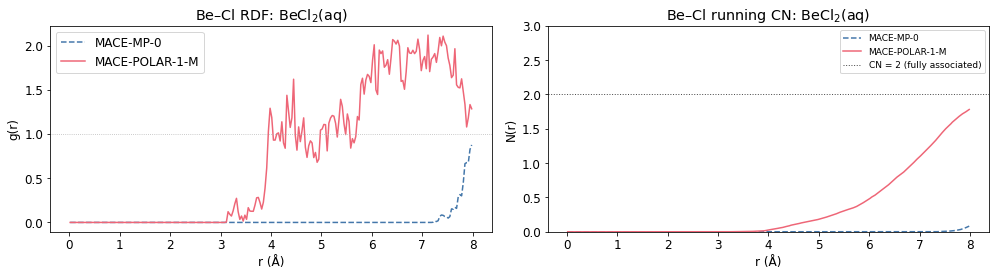

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, ff in enumerate(('MP0', 'POLAR')):
    r, g, n = load_travis(('BeCl2', ff), 'rdf_Be_Cl_[Be1r_Cl1o]_long.csv')
    axes[0].plot(r, g, color=cset[i], ls=LS[ff], label=FF_LABELS[ff])
    axes[1].plot(r, n, color=cset[i], ls=LS[ff], label=FF_LABELS[ff])

axes[0].axhline(1, color='0.7', lw=0.8, ls=':')
axes[0].set_xlabel('r (Å)')
axes[0].set_ylabel('g(r)')
axes[0].set_title(r'Be–Cl RDF: BeCl$_2$(aq)')
axes[0].legend()

axes[1].axhline(2, color='0.3', lw=1, ls=':', label='CN = 2 (fully associated)')
axes[1].set_ylim(0, 3)
axes[1].set_xlabel('r (Å)')
axes[1].set_ylabel('N(r)')
axes[1].set_title(r'Be–Cl running CN: BeCl$_2$(aq)')
axes[1].legend(fontsize=9)

plt.tight_layout()

for ff in ('MP0', 'POLAR'):
    r, g, n = load_travis(('BeCl2', ff), 'rdf_Be_Cl_[Be1r_Cl1o]_long.csv')
    pk_i = int(np.argmax(g))
    mn_i = pk_i + int(g[pk_i:pk_i + 30].argmin())
    print(f'{FF_LABELS[ff]:<22}: peak {r[pk_i]:.2f} Å   CN = {n[mn_i]:.2f}')

---
## Diffusion (MSD)

Mean squared displacement via the Einstein relation.  `diffusive_window` locates the
Fickian regime automatically; D is fitted over that window.

In [18]:
msds_h2o = {}
Ds_h2o   = {}
msds_be  = {}
Ds_be    = {}
Be_form  = {}

for key, t in trajs.items():
    lags, msd, _ = t.msd('H2O', dt=dt * dump_interval)
    mask, _, _, _ = diffusive_window(lags, msd)
    msds_h2o[key] = (lags, msd)
    Ds_h2o[key]   = fit_D(lags, msd, mask)

    be_forms = {f: c for f, c in t.summary().items() if 'Be' in f}
    if be_forms:
        formula = max(be_forms, key=be_forms.get)
        Be_form[key] = formula
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            lags_b, msd_b, _ = t.msd(formula, dt=dt * dump_interval)
        valid = ~np.isnan(msd_b)
        if valid.sum() > 10:
            mask_b, _, _, _ = diffusive_window(lags_b[valid], msd_b[valid])
            msds_be[key] = (lags_b[valid], msd_b[valid])
            Ds_be[key]   = fit_D(lags_b[valid], msd_b[valid], mask_b)

print('MSD computed.')
print(f'Be complex formulas: {Be_form}')

MSD computed.
Be complex formulas: {('Be2+', 'MP0'): 'BeH14O7', ('BeCl2', 'MP0'): 'BeH12O6', ('Be2+', 'POLAR'): 'BeH10O5', ('BeCl2', 'POLAR'): 'BeH10O5'}


/tmp/ipykernel_61039/1175020027.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=9)


System                                 D(H₂O) (m²/s)     D(Be) (m²/s)
----------------------------------------------------------------------
  Be$^{2+}$ MACE-MP-0                      9.357e-08                —
  BeCl$_2$ MACE-MP-0                       1.342e-07                —
  Be$^{2+}$ MACE-POLAR-1-M                 3.040e-08                —
  BeCl$_2$ MACE-POLAR-1-M                  2.692e-08                —


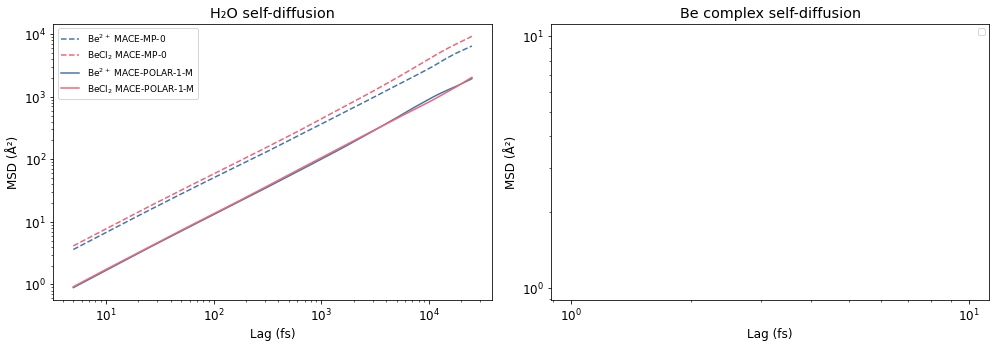

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key, (lags, msd) in msds_h2o.items():
    sys, ff = key
    axes[0].plot(lags, msd, color=C[sys], ls=LS[ff], lw=LW, label=LABELS[key])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Lag (fs)')
axes[0].set_ylabel('MSD (Å²)')
axes[0].set_title('H₂O self-diffusion')
axes[0].legend(fontsize=9)

for key, (lags, msd) in msds_be.items():
    sys, ff = key
    axes[1].plot(lags, msd, color=C[sys], ls=LS[ff], lw=LW,
                 label=f'{LABELS[key]}  ({Be_form[key]})')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Lag (fs)')
axes[1].set_ylabel('MSD (Å²)')
axes[1].set_title('Be complex self-diffusion')
axes[1].legend(fontsize=9)

plt.tight_layout()

print(f'{"System":<35} {"D(H₂O) (m²/s)":>16} {"D(Be) (m²/s)":>16}')
print('-' * 70)
for key in trajs:
    d_be = f'{Ds_be[key]:.3e}' if key in Ds_be else '—'
    print(f'  {LABELS[key]:<33} {Ds_h2o[key]:>16.3e} {d_be:>16}')

---
## VACF

Velocity autocorrelation function at full 0.5 fs resolution from the log files.
Normalised to VACF(0) = 1 for direct comparison.  The first 500 fs capture
librational and collision-timescale dynamics.

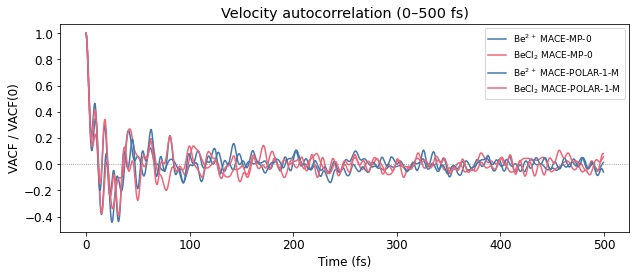

In [20]:
vacfs = {key: load_vacf(logpath) for key, logpath in LOGS.items()}

N_PLOT = int(500 / dt)  # samples to show (0–500 fs)

fig, ax = plt.subplots(figsize=(9, 4))

for key, (t, vacf) in vacfs.items():
    sys, ff = key
    ax.plot(t[:N_PLOT], vacf[:N_PLOT] / vacf[0],
            color=C[sys], ls=LS[ff], lw=LW, label=LABELS[key])

ax.axhline(0, color='0.5', lw=0.8, ls=':')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('VACF / VACF(0)')
ax.set_title('Velocity autocorrelation (0–500 fs)')
ax.legend(fontsize=9)
plt.tight_layout()

---
## VDOS

Vibrational density of states via FFT of the Hann-windowed VACF (`read_vdos`).
Each spectrum is normalised to its maximum within 0–4500 cm⁻¹ and smoothed with a
Gaussian (σ = 20 samples).

System                                  Libration (cm⁻¹)   HOH bend   O–H str.
-----------------------------------------------------------------------------
  Be$^{2+}$ MACE-MP-0                                658       1615       3312
  BeCl$_2$ MACE-MP-0                                 718       1566       3388
  Be$^{2+}$ MACE-POLAR-1-M                           414       1642       3709
  BeCl$_2$ MACE-POLAR-1-M                            530       1666       3655


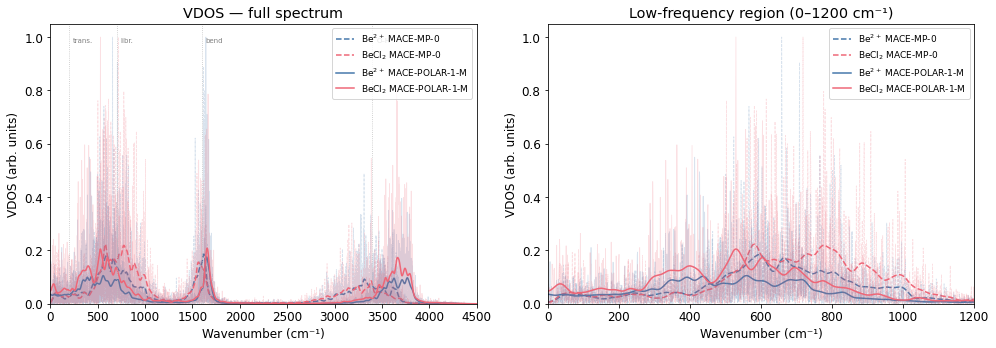

In [35]:
wn_ref, _ = read_vdos(LOGS[('Be2+', 'MP0')], dt=dt)
mask_full = (wn_ref >= 0) & (wn_ref <= 4500)
mask_lo   = (wn_ref >= 0) & (wn_ref <= 1200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key in trajs:
    sys, ff = key
    wn, vdos = read_vdos(LOGS[key], dt=dt)
    norm = vdos[mask_full].max()
    arr  = vdos / norm
    s    = smooth(arr, sigma=20)
    axes[0].plot(wn[mask_full], arr[mask_full], color=C[sys], ls=LS[ff], alpha=0.2, lw=0.8)
    axes[0].plot(wn[mask_full], s[mask_full],   color=C[sys], ls=LS[ff], lw=LW, label=LABELS[key])
    axes[1].plot(wn[mask_lo],   arr[mask_lo],   color=C[sys], ls=LS[ff], alpha=0.2, lw=0.8)
    axes[1].plot(wn[mask_lo],   s[mask_lo],     color=C[sys], ls=LS[ff], lw=LW, label=LABELS[key])

for nu, lbl in [(200, 'trans.'), (700, 'libr.'), (1600, 'bend'), (3400, 'O–H')]:
    axes[0].axvline(nu, color='0.75', lw=0.8, ls=':')
    axes[0].text(nu + 40, 0.95, lbl, fontsize=7, color='0.5',
                 transform=axes[0].get_xaxis_transform(), va='top')

axes[0].set_xlim(0, 4500)
axes[0].set_ylim(0)
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_ylabel('VDOS (arb. units)')
axes[0].set_title('VDOS — full spectrum')
axes[0].legend(fontsize=9)

axes[1].set_xlim(0, 1200)
axes[1].set_ylim(0)
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('VDOS (arb. units)')
axes[1].set_title('Low-frequency region (0–1200 cm⁻¹)')
axes[1].legend(fontsize=9)

plt.tight_layout()

print(f'{"System":<35} {"Libration (cm⁻¹)":>20} {"HOH bend":>10} {"O–H str.":>10}')
print('-' * 77)
for key in trajs:
    wn, vdos = read_vdos(LOGS[key], dt=dt)
    peaks = []
    for lo, hi in [(300, 1000), (1200, 2000), (2800, 4000)]:
        m = (wn >= lo) & (wn <= hi)
        peaks.append(f'{wn[m][np.argmax(vdos[m])]:6.0f}')
    print(f'  {LABELS[key]:<33} {peaks[0]:>20} {peaks[1]:>10} {peaks[2]:>10}')